In [1]:
import sys
print(sys.version)

3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]


In [3]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [8]:
!pip install seaborn matplotlib pandas numpy scikit-learn

In [5]:
csv_url = "creditcard.csv"
df = pd.read_csv(csv_url)

In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


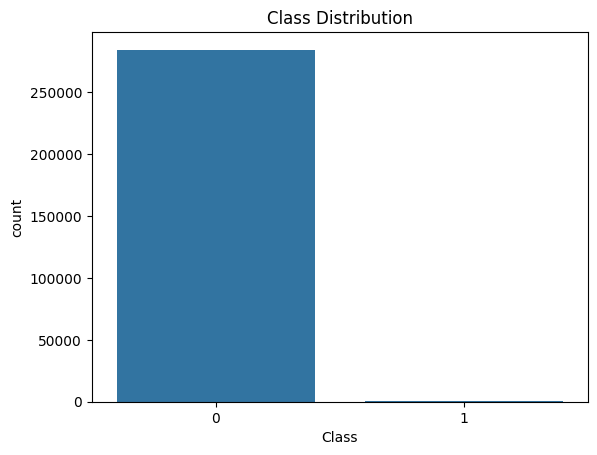

In [7]:
#Plot the class distribution
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()

In [8]:
#Feature Scaling
#fit=leanrn the mean and std, transform=applies the standardization formula
#reshape(rows, columns) where -1 = tell the machine to figure out on its own
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['Time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))


In [9]:
X_train, X_test, y_train, y_test =  train_test_split(df.drop('Class', axis=1), df['Class'], test_size=0.2, random_state=42)

In [10]:
from sklearn.metrics import precision_score, recall_score, classification_report, confusion_matrix

In [12]:

#Build a simple feedforward neural network
#`Sequential` means layers are stacked **one after another**, where output of one layer feeds into the next.

model = tf.keras.models.Sequential([
        tf.keras.layers.Dense(128, input_dim=X_train.shape[1], activation='relu'), #input_dim=X_train.shape[1] = number of columns/ features
        tf.keras.layers.Dropout(0.3), #randomly dropping out 30% of neurons to avoid overfitting
        tf.keras.layers.Dense(64,  activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid') #sigmoid squishes stricty between 0 and 1
                ])

learning_rate = 0.001
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=1)

y_pred = (model.predict(X_test) > 0.5).astype(int)

def evaluate_model(y_true, y_pred):
    print("Precision Score:", precision_score(y_test, y_pred))
    print("Recall Score:", recall_score(y_test, y_pred))
    print("Classificatiob Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
print(evaluate_model(y_test, y_pred))


Epoch 1/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 32s 4ms/step - accuracy: 0.9991 - loss: 0.0065 - val_accuracy: 0.9993 - val_loss: 0.0035
Epoch 2/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - accuracy: 0.9993 - loss: 0.0040 - val_accuracy: 0.9993 - val_loss: 0.0031
Epoch 3/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.9994 - loss: 0.0036 - val_accuracy: 0.9994 - val_loss: 0.0030
Epoch 4/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9993 - val_loss: 0.0035
Epoch 5/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9993 - val_loss: 0.0030
Epoch 6/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 0.9993 - val_loss: 0.0037
Epoch 7/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9994 - val_loss: 0.0027
Epoch 8/10
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - accuracy: 0.9994 - loss: 0

In [13]:
from sklearn.ensemble import IsolationForest
if_model = IsolationForest(contamination=0.02, random_state=42) #contamination = the proportion of outliers in the data set
if_model.fit(X_train) #Y_train is not needed because it is unsupervised
if_preds = if_model.predict(X_test)
if_preds[if_preds == 1] = 0  #Normal -> 0
if_preds[if_preds == -1] = 1 #Fradulent -> 1
print("Isolation Forest:")
print(evaluate_model(y_test, if_preds))

Isolation Forest:
Precision Score: 0.06568712186689715
Recall Score: 0.7755102040816326
Classificatiob Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.78      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.88      0.56     56962
weighted avg       1.00      0.98      0.99     56962

Confusion Matrix:
[[55783  1081]
 [   22    76]]
None


In [15]:
from sklearn.cluster import KMeans

In [16]:
kmeans_model = KMeans(n_clusters=2, random_state=42)
kmeans_model.fit(X_train.values)
kmeans_preds = kmeans_model.predict(X_test)
print("\nK-Means:")
print(evaluate_model(y_test, kmeans_preds))


K-Means:
Precision Score: 0.0026656004264960682
Recall Score: 0.8163265306122449
Classificatiob Report:
              precision    recall  f1-score   support

           0       1.00      0.47      0.64     56864
           1       0.00      0.82      0.01        98

    accuracy                           0.47     56962
   macro avg       0.50      0.64      0.32     56962
weighted avg       1.00      0.47      0.64     56962

Confusion Matrix:
[[26932 29932]
 [   18    80]]
None


C:\Users\risoe\anaconda3\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(


In [17]:
from sklearn.svm import OneClassSVM

In [19]:
svm_model = OneClassSVM(kernel='rbf', nu=0.01)
svm_model.fit(X_train)
svm_preds = svm_model.predict(X_test)
svm_preds[svm_preds == 1] = 0
svm_preds[svm_preds == -1] = 1
print("\nOne-Class SVM:")
evaluate_model(y_test, svm_preds)


One-Class SVM:
Precision Score: 0.08823529411764706
Recall Score: 0.6122448979591837
Classificatiob Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.09      0.61      0.15        98

    accuracy                           0.99     56962
   macro avg       0.54      0.80      0.57     56962
weighted avg       1.00      0.99      0.99     56962

Confusion Matrix:
[[56244   620]
 [   38    60]]
